# 전처리 확인과 초기 Target 조건 선정
초기 규격: **3,200 Å ± 400 Å**. 원본 요약표와 유효값 재계산을 구분합니다.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.detailed_analysis import evaluate_conditions, follow_up_estimate
from src.render_detailed import render
render(ROOT)

## 1. 계측 품질과 결측 위치
현재 파일에서 확인되는 결측을 보여줍니다. GOF 임계값이나 삭제 이력은 임의로 가정하지 않습니다.

In [2]:
quality = pd.read_csv(ROOT/'data/measurement_quality_summary.csv')
missing = pd.read_csv(ROOT/'data/missing_measurement_audit.csv')
display(quality[quality.missing_thickness_count > 0])
display(missing)
assert len(missing) == 9

,condition_id,gof_min,gof_max,valid_thickness_count,missing_thickness_count
22,23,0.812330,0.979875,44,5
24,25,0.970035,0.979706,45,4


,condition_id,recipe,wf,point,gof
0,23,FT0524_run21,8,45,0.833123
1,23,FT0524_run21,8,46,0.819800
2,23,FT0524_run21,8,47,0.823120
3,23,FT0524_run21,8,48,0.823450
4,23,FT0524_run21,8,49,0.812330
5,25,FT0524_run23,10,37,0.973382
6,25,FT0524_run23,10,40,0.973266
7,25,FT0524_run23,10,43,0.972898
8,25,FT0524_run23,10,47,0.978109


## 2. 원본 요약표와 재계산 대조
Run21은 유효값 44개의 평균과 요약표 평균이 다릅니다.

In [3]:
audit = pd.read_csv(ROOT/'data/condition_evaluation.csv')
display(audit.loc[audit.average_difference_a.abs() > 0.01, ['recipe','average_thickness','recomputed_average_a','average_difference_a','valid_point_count']])

,recipe,average_thickness,recomputed_average_a,average_difference_a,valid_point_count
22,FT0524_run21,2549.726873,2552.971059,3.244187,44


## 3. 관측 MIN–MAX가 규격 내인 조건의 Target 차이 비교
Uniformity=(MAX−MIN)/(2×AVG)×100. Run23은 45개 유효 위치의 결과이며 4개 누락은 재계측 대상입니다.

,recipe,si2h6_flow,power,temperature,time_sec,average_thickness,max_thickness,min_thickness,range,standard_deviation,uniformity_pct,dep_rate_a_per_sec,target_gap_a,observed_points_within_spec
24,FT0524_run23,175,300,300,50,3154.614376,3470.215099,2833.027061,637.188038,187.482939,10.099302,63.092288,45.385624,True
20,FT0524_run19,195,300,300,45,3143.877551,3439.554157,2815.919398,623.634759,183.810590,9.918242,69.863946,56.122449,True


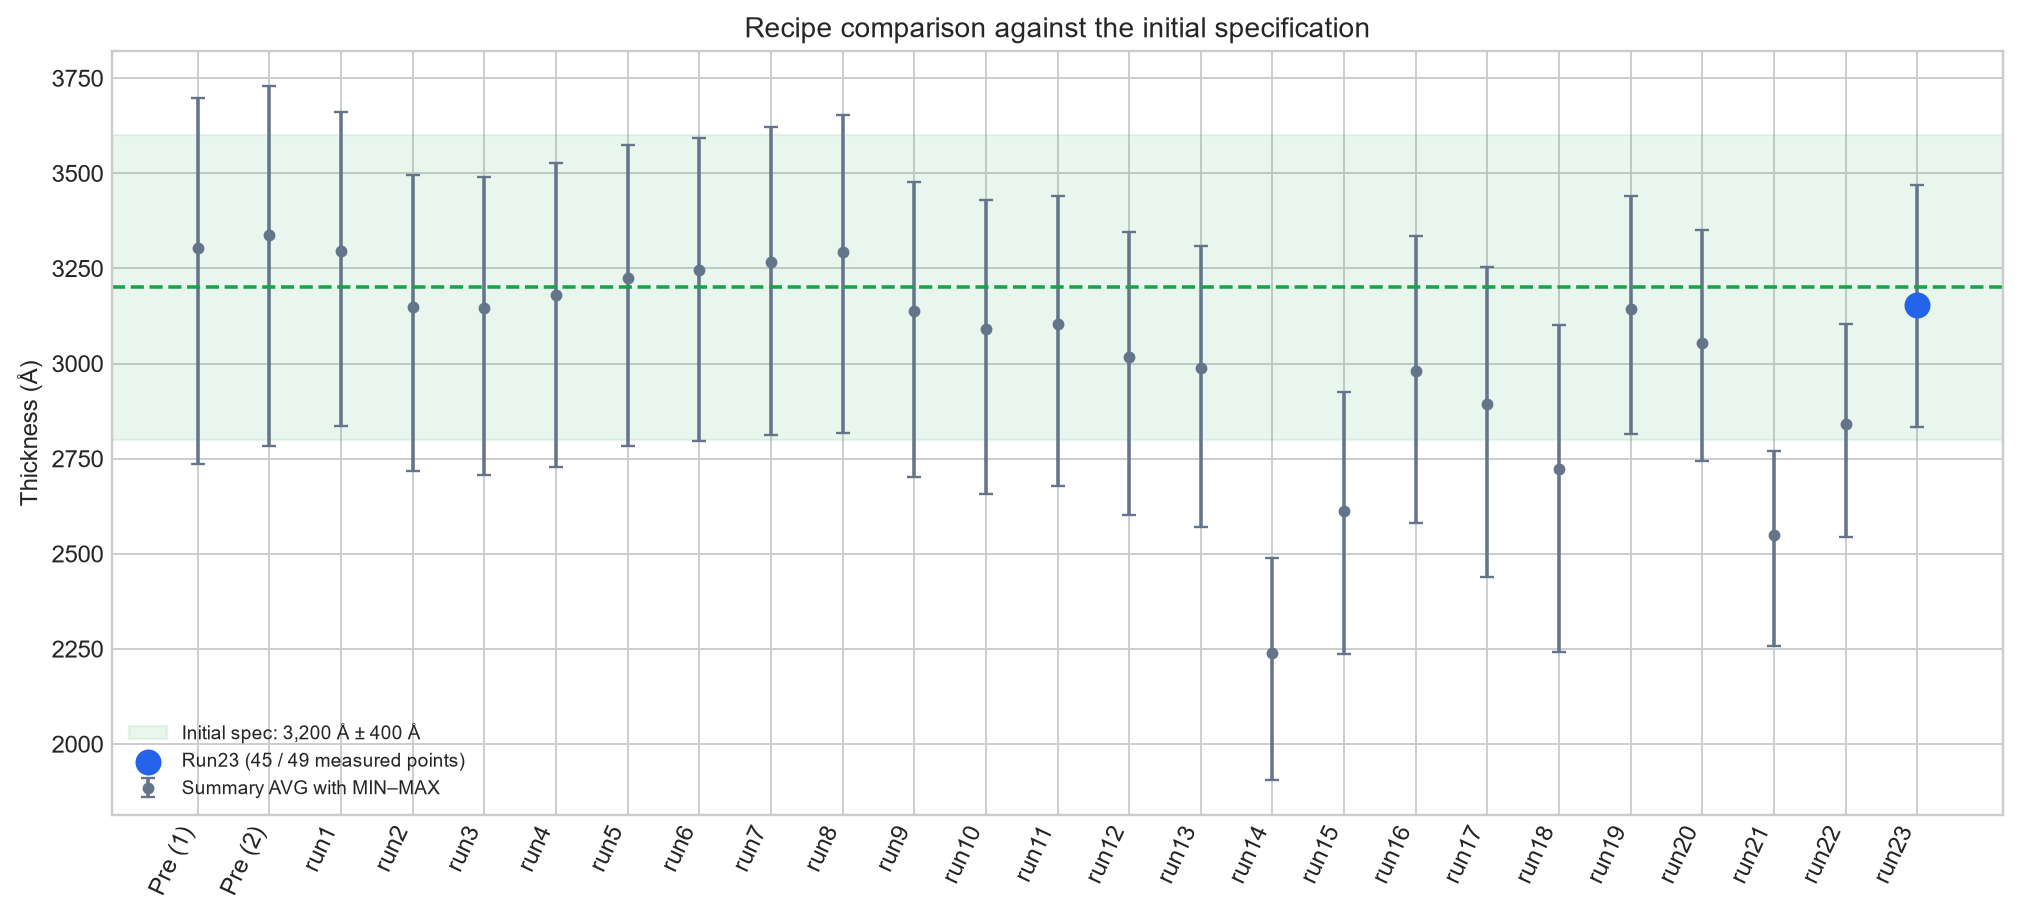

In [4]:
conditions = pd.read_csv(ROOT/'data/deposition_condition_summary.csv')
evaluated = evaluate_conditions(conditions)
candidates = evaluated[evaluated.observed_points_within_spec].sort_values('target_gap_a')
display(candidates)
assert candidates.iloc[0].recipe == 'FT0524_run23'
display(Image(filename=str(ROOT/'images/initial_spec_comparison.png')))

## 결과
Run19와 Run23의 관측 MIN–MAX가 초기 규격에 들어옵니다. Target 차이가 더 작은 Run23을 우선 후보로 선정하되 누락 위치와 반복 실험을 확인해야 합니다.